<a href="https://colab.research.google.com/github/Lawson-Dong/ESINDy_infra/blob/main/Lorenz96_and_Duffing_SINDy_(using_another_infra).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Experiment: Lorenz 96 (High-Dimensional Chaos)
Running Benchmark: Lorenz96 (10 runs per setting)

--- Noise Level: sigma = 0.0 ---
  Standard SINDy  -> One-step RMSE: 0.073730 ± 0.001235 | Auto RMSE: 4.050438 ± 0.342563 | Time: 0.14s ± 0.01s
  Bagging         -> One-step RMSE: 0.073544 ± 0.001280 | Auto RMSE: 4.050880 ± 0.342590 | Time: 5.28s ± 0.51s
  Boosting        -> One-step RMSE: 0.068975 ± 0.000999 | Auto RMSE: 4.054842 ± 0.342847 | Time: 3.56s ± 0.68s
  Stacking        -> One-step RMSE: 0.073975 ± 0.001343 | Auto RMSE: 4.050482 ± 0.342614 | Time: 35.03s ± 3.85s

--- Noise Level: sigma = 0.1 ---
  Standard SINDy  -> One-step RMSE: 0.121011 ± 0.001469 | Auto RMSE: 4.071329 ± 0.266391 | Time: 0.15s ± 0.02s
  Bagging         -> One-step RMSE: 0.120317 ± 0.001477 | Auto RMSE: 4.072719 ± 0.270402 | Time: 6.23s ± 0.69s
  Boosting        -> One-step RMSE: 0.119305 ± 0.001403 | Auto RMSE: 4.072366 ± 0.266421 | Time: 3.83s ± 0.55s
  Stacking        -> One-step RMSE: 0.121127 ± 0

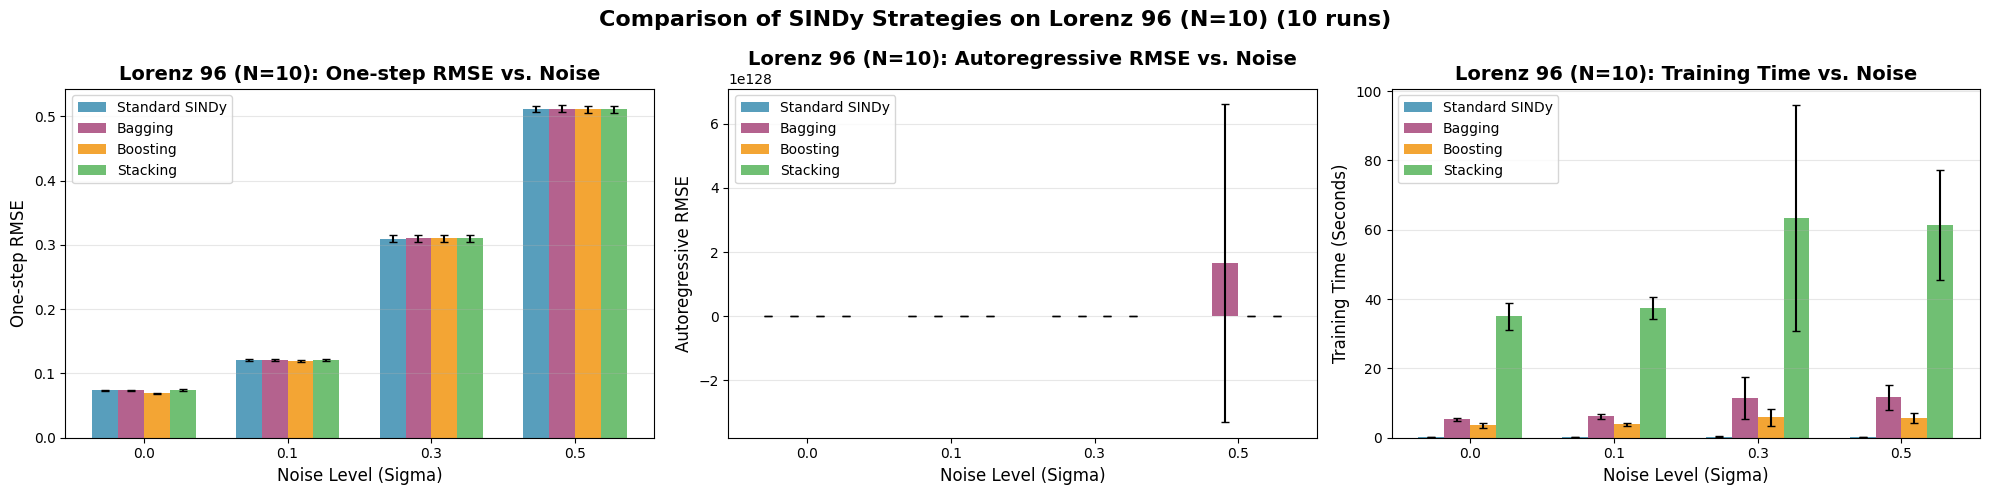



Starting Experiment: Duffing Oscillator
Running Benchmark: Duffing (10 runs per setting)

--- Noise Level: sigma = 0.0 ---
  Standard SINDy  -> One-step RMSE: 0.009679 ± 0.000000 | Auto RMSE: 1.288352 ± 0.000000 | Time: 0.01s ± 0.00s
  Bagging         -> One-step RMSE: 0.009679 ± 0.000004 | Auto RMSE: 1.288627 ± 0.006905 | Time: 0.13s ± 0.03s
  Boosting        -> One-step RMSE: 0.009811 ± 0.000000 | Auto RMSE: 1.040270 ± 0.000000 | Time: 0.07s ± 0.01s
  Stacking        -> One-step RMSE: 0.009747 ± 0.000000 | Auto RMSE: 1.437892 ± 0.000000 | Time: 0.76s ± 0.13s

--- Noise Level: sigma = 0.1 ---
  Standard SINDy  -> One-step RMSE: 0.100211 ± 0.002866 | Auto RMSE: 1.272502 ± 0.100529 | Time: 0.00s ± 0.00s
  Bagging         -> One-step RMSE: 0.100211 ± 0.002866 | Auto RMSE: 1.270206 ± 0.102401 | Time: 0.13s ± 0.03s
  Boosting        -> One-step RMSE: 0.100255 ± 0.002865 | Auto RMSE: 1.025724 ± 0.079403 | Time: 0.07s ± 0.01s
  Stacking        -> One-step RMSE: 0.100196 ± 0.002867 | Auto R

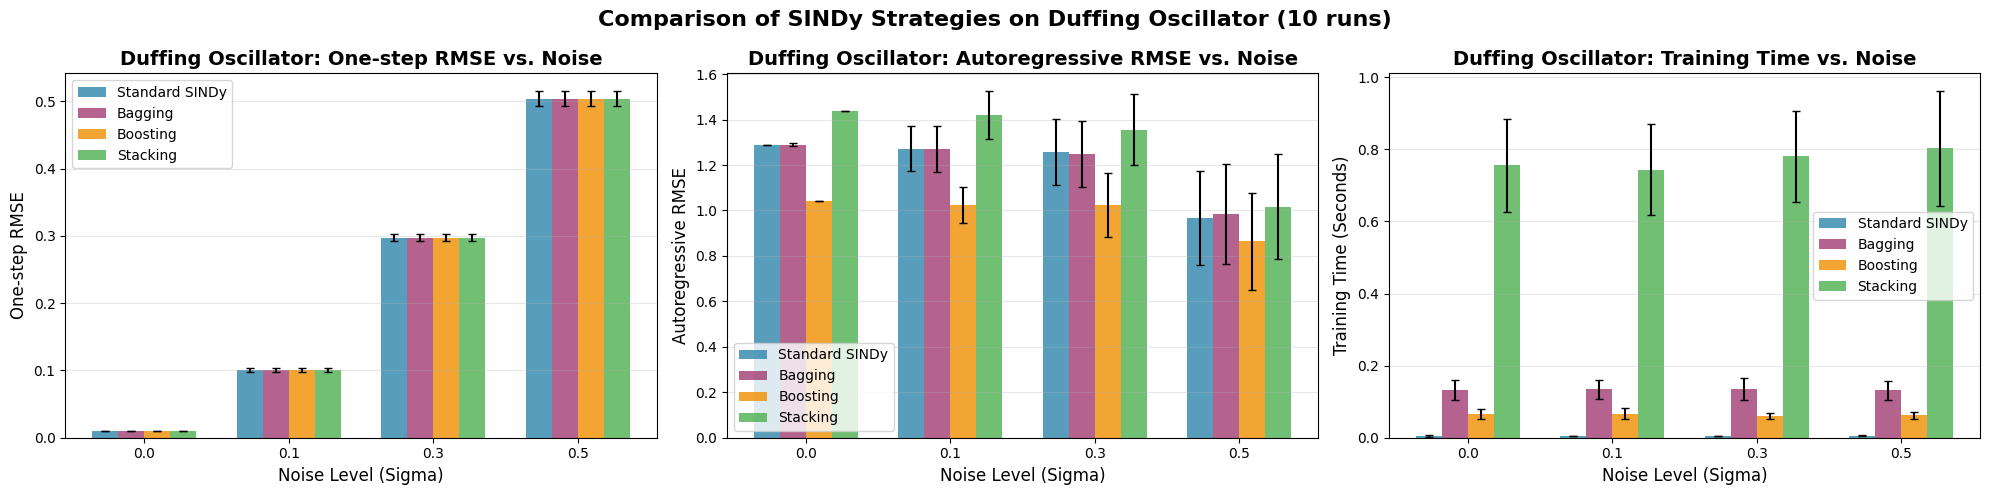

Experiment completed successfully!


In [ ]:
# =============================================================================
# Part 0: Install Dependencies (If running in Colab)
# =============================================================================
!pip install scikit-learn matplotlib numpy scipy -q

# =============================================================================
# Part 1: Import Libraries
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.signal import savgol_filter
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
import time

warnings.filterwarnings('ignore')

# =============================================================================
# Part 2: Base SINDy Framework
# =============================================================================

class BaseSINDy:
    """Base class for SINDy with common utility functions."""
    def __init__(self, **kwargs):
        self.poly_degree = kwargs.get('poly_degree', 2)
        self.threshold = kwargs.get('threshold', 0.15)
        self.sg_window = kwargs.get('sg_window', 11)
        self.sg_order = kwargs.get('sg_order', 3)
        self.use_reduced_features = kwargs.get('use_reduced_features', False)
        self.feature_names = None
        self.poly = None

    def _compute_derivative_sg(self, X, dt):
        """Compute robust derivatives using Savitzky-Golay filter."""
        n_samples, n_states = X.shape
        dX = np.zeros_like(X)
        for i in range(n_states):
            X_smoothed = savgol_filter(X[:, i], self.sg_window, self.sg_order)
            dX[:, i] = np.gradient(X_smoothed, dt)
        return dX

    def _create_polynomial_features(self, X, fit=False):
        """Create polynomial feature library."""
        if fit or not hasattr(self, 'poly'):
            self.poly = PolynomialFeatures(degree=self.poly_degree, include_bias=False)
            Theta = self.poly.fit_transform(X)
        else:
            Theta = self.poly.transform(X)
        return Theta


class StandardSINDy(BaseSINDy):
    """Standard SINDy with Lasso (baseline)."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.coefficients = None

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        n_features = Theta.shape[1]
        self.coefficients = np.zeros((n_states, n_features))
        for j in range(n_states):
            lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=42)
            lasso.fit(Theta, dX[:, j])
            coef = lasso.coef_
            coef[np.abs(coef) < self.threshold] = 0
            self.coefficients[j] = coef
        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        return Theta @ self.coefficients.T


class BaggingSINDy(BaseSINDy):
    """Bagging Ensemble SINDy."""
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.subsample_ratio = kwargs.pop('subsample_ratio', 0.8)
        self.models = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        self.models = []

        for i in range(self.n_estimators):
            try:
                indices = np.random.choice(n_samples, int(n_samples * self.subsample_ratio), replace=True)
                Theta_sample = Theta[indices]
                dX_sample = dX[indices]

                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_sample, dX_sample[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                self.models.append(np.array(coeffs))
            except Exception:
                continue

        if len(self.models) == 0:
            raise RuntimeError("All models failed to train.")
        self.final_coefficients = np.median(self.models, axis=0)
        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        return Theta @ self.final_coefficients.T


class BoostingSINDy(BaseSINDy):
    """Boosting Ensemble SINDy (Residual fitting)."""
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.learning_rate = kwargs.pop('learning_rate', 0.1)
        self.early_stopping = kwargs.pop('early_stopping', True)
        self.early_stopping_tol = kwargs.pop('early_stopping_tol', 1e-4)
        self.patience = kwargs.pop('patience', 5)
        self.models = []
        self.final_coefficients = None
        self.base_predictors = []
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX_true = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        self.final_coefficients = np.zeros((n_states, Theta.shape[1]))
        self.models = []
        self.base_predictors = []
        dX_residual = dX_true.copy()

        best_loss = np.inf
        patience_counter = 0

        for i in range(self.n_estimators):
            try:
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta, dX_residual[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)

                self.models.append(coeffs)
                self.final_coefficients += self.learning_rate * coeffs
                dX_pred = Theta @ coeffs.T
                dX_residual -= self.learning_rate * dX_pred

                if self.early_stopping:
                    current_loss = np.mean(dX_residual**2)
                    if (best_loss - current_loss) / (best_loss + 1e-10) < self.early_stopping_tol:
                        patience_counter += 1
                        if patience_counter >= self.patience:
                            if verbose:
                                print(f"Early stopping at iteration {i}, loss = {current_loss:.6f}")
                            break
                    else:
                        best_loss = current_loss
                        patience_counter = 0

            except Exception:
                continue
        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        return Theta @ self.final_coefficients.T


# =============================================================================
# Part 2.5: Traditional Stacking SINDy (Fully Corrected)
# =============================================================================
class StackingSINDy(BaseSINDy):
    """Stacking Ensemble SINDy (Traditional Architecture)."""

    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.meta_alpha = kwargs.pop('meta_alpha', 1.0)
        self.base_models = []
        self.meta_models = []
        self.final_coefficients = None
        self.meta_learner_type = 'ridge' # 'ridge' or 'lasso'
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X, fit=True)
        n_features = Theta.shape[1]

        # 1. 训练 K 个基模型 (在全部训练数据上)
        self.base_models = []
        for i in range(self.n_estimators):
            try:
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta, dX[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.base_models.append(coeffs)
            except Exception:
                continue

        if len(self.base_models) == 0:
            raise RuntimeError("All base models failed.")

        # 2. 通过 KFold 生成元学习器的训练数据
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        n_base_models = len(self.base_models)

        # 存储元学习器的特征和标签
        X_meta_all = [[] for _ in range(n_states)]
        y_meta_all = [[] for _ in range(n_states)]

        for train_idx, val_idx in kf.split(X):
            Theta_train, Theta_val = Theta[train_idx], Theta[val_idx]
            dX_val = dX[val_idx]

            # 临时训练基模型 (仅限当前 Fold 的训练集)
            temp_base_preds = []
            for i in range(n_base_models):
                temp_coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_train, dX[train_idx][:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    temp_coeffs.append(coef)
                temp_coeffs = np.array(temp_coeffs)
                pred_val = Theta_val @ temp_coeffs.T
                temp_base_preds.append(pred_val)

            # 收集当前 Fold 的元学习器数据
            n_val = len(val_idx)
            for j in range(n_states):
                X_meta_j = np.array([pred[:, j] for pred in temp_base_preds]).T  # (n_val, n_base_models)
                X_meta_all[j].append(X_meta_j)
                y_meta_all[j].append(dX_val[:, j])

        # 3. 训练元学习器并计算最终系数
        self.meta_models = []
        self.final_coefficients = np.zeros((n_states, n_features))

        for j in range(n_states):
            X_meta_j = np.vstack(X_meta_all[j])
            y_meta_j = np.concatenate(y_meta_all[j])

            if self.meta_learner_type == 'ridge':
                meta_model = Ridge(alpha=self.meta_alpha)
            elif self.meta_learner_type == 'lasso':
                meta_model = Lasso(alpha=self.meta_alpha, max_iter=10000)
            else:
                raise ValueError("Meta-learner must be 'ridge' or 'lasso'")

            meta_model.fit(X_meta_j, y_meta_j)
            self.meta_models.append(meta_model)

            alpha_weights = meta_model.coef_
            final_coeff_j = np.zeros(n_features)
            for k in range(n_base_models):
                final_coeff_j += alpha_weights[k] * self.base_models[k][j]

            self.final_coefficients[j] = final_coeff_j

        return self

    def predict_derivative(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X, fit=False)
        return Theta @ self.final_coefficients.T


# =============================================================================
# Part 3: Benchmark Systems Definition
# =============================================================================

def generate_lorenz96_data(N=10, F=8.0, t_max=10.0, dt=0.01, x0=None, noise_std=0.0, seed=None):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    def lorenz96_system(x, t):
        dxdt = np.zeros_like(x)
        for i in range(N):
            dxdt[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] + F
        return dxdt
    t = np.arange(0, t_max, dt)
    if x0 is None:
        x0 = rng.uniform(-1, 1, N)
    X_true = odeint(lorenz96_system, x0, t)
    if noise_std > 0:
        X_noisy = X_true + rng.normal(0, noise_std, X_true.shape)
    else:
        X_noisy = X_true
    return t, X_true, X_noisy

def generate_duffing_data(delta=0.3, gamma=1.2, t_max=10.0, dt=0.01, x0=[1.0, 0.0], noise_std=0.0, seed=None):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    def duffing_system(state, t):
        x, y = state
        dx = y
        dy = x - x**3 - delta * y + gamma * np.cos(t)
        return [dx, dy]
    t = np.arange(0, t_max, dt)
    X_true = odeint(duffing_system, x0, t)
    if noise_std > 0:
        X_noisy = X_true + rng.normal(0, noise_std, X_true.shape)
    else:
        X_noisy = X_true
    return t, X_true, X_noisy


# =============================================================================
# Part 4: Integration and Evaluation Functions
# =============================================================================

def one_step_prediction_rk4(model, X_test_true, dt):
    n_steps = len(X_test_true)
    X_pred = np.zeros_like(X_test_true)
    X_pred[0] = X_test_true[0]
    def f(state):
        if state.ndim == 1:
            state = state.reshape(1, -1)
        return model.predict_derivative(state)[0]
    for i in range(n_steps - 1):
        x = X_test_true[i].flatten()
        k1 = f(x)
        if np.any(np.isnan(k1)):
            X_pred[i+1:] = np.nan
            break
        k2 = f(x + 0.5 * dt * k1)
        if np.any(np.isnan(k2)):
            X_pred[i+1:] = np.nan
            break
        k3 = f(x + 0.5 * dt * k2)
        if np.any(np.isnan(k3)):
            X_pred[i+1:] = np.nan
            break
        k4 = f(x + dt * k3)
        if np.any(np.isnan(k4)):
            X_pred[i+1:] = np.nan
            break
        X_pred[i+1] = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return X_pred

def autoregressive_prediction_rk4(model, x0, dt, n_steps):
    X_pred = np.zeros((n_steps, len(x0)))
    X_pred[0] = x0
    def f(state):
        if state.ndim == 1:
            state = state.reshape(1, -1)
        return model.predict_derivative(state)[0]
    for i in range(n_steps - 1):
        x = X_pred[i].flatten()
        k1 = f(x)
        if np.any(np.isnan(k1)):
            X_pred[i+1:] = np.nan
            break
        k2 = f(x + 0.5 * dt * k1)
        if np.any(np.isnan(k2)):
            X_pred[i+1:] = np.nan
            break
        k3 = f(x + 0.5 * dt * k2)
        if np.any(np.isnan(k3)):
            X_pred[i+1:] = np.nan
            break
        k4 = f(x + dt * k3)
        if np.any(np.isnan(k4)):
            X_pred[i+1:] = np.nan
            break
        X_pred[i+1] = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return X_pred

def calculate_rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if np.sum(mask) == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))


# =============================================================================
# Part 5: Main Experiment Runner
# =============================================================================

def run_experiment_for_system(system_name, generate_data_func, config, X0_test, noise_levels, n_runs=10, verbose=True):
    methods = ['standard', 'bagging', 'boosting', 'stacking']
    method_names = {
        'standard': 'Standard SINDy',
        'bagging': 'Bagging',
        'boosting': 'Boosting',
        'stacking': 'Stacking'
    }

    results = {
        m: {
            'one_step': {'rmse_avg': [], 'rmse_std': [], 'time_avg': [], 'time_std': []},
            'autoregressive': {'rmse_avg': [], 'rmse_std': [], 'time_avg': [], 'time_std': []}
        } for m in methods
    }

    if verbose:
        print(f"Running Benchmark: {system_name} ({n_runs} runs per setting)")
        print("="*80)

    for noise_std in noise_levels:
        if verbose:
            print(f"\n--- Noise Level: sigma = {noise_std} ---")

        runs_one_step = {m: {'rmse': [], 'time': []} for m in methods}
        runs_autoregressive = {m: {'rmse': [], 'time': []} for m in methods}

        for run in range(n_runs):
            seed = run + int(noise_std*1000)
            _, _, X_noisy_train = generate_data_func(noise_std=noise_std, seed=seed, **config['system_kwargs'])
            _, X_true_test, X_noisy_test = generate_data_func(noise_std=noise_std, seed=seed+1000, **config['system_kwargs'])
            eval_steps = int(config['eval_window'] / config['dt'])
            X_true_test_eval = X_true_test[:eval_steps]
            X_noisy_test_eval = X_noisy_test[:eval_steps]

            for method_name in methods:
                if method_name == 'standard':
                    model = StandardSINDy(**config['sindy_kwargs'])
                elif method_name == 'bagging':
                    model = BaggingSINDy(**config['sindy_kwargs'])
                elif method_name == 'boosting':
                    model = BoostingSINDy(**config['sindy_kwargs'])
                else:
                    model = StackingSINDy(**config['sindy_kwargs'])

                start_time = time.time()
                model.fit(X_noisy_train, dt=config['dt'], verbose=False)
                elapsed = time.time() - start_time

                X_pred_one = one_step_prediction_rk4(model, X_noisy_test_eval, config['dt'])
                rmse_one = calculate_rmse(X_true_test_eval.flatten(), X_pred_one.flatten())

                X_pred_auto = autoregressive_prediction_rk4(model, X_noisy_test_eval[0], config['dt'], eval_steps)
                rmse_auto = calculate_rmse(X_true_test_eval.flatten(), X_pred_auto.flatten())

                runs_one_step[method_name]['rmse'].append(rmse_one)
                runs_one_step[method_name]['time'].append(elapsed)
                runs_autoregressive[method_name]['rmse'].append(rmse_auto)
                runs_autoregressive[method_name]['time'].append(elapsed)

        for m in methods:
            for pred_type in ['one_step', 'autoregressive']:
                runs_data = runs_one_step if pred_type == 'one_step' else runs_autoregressive
                rmse_list = runs_data[m]['rmse']
                time_list = runs_data[m]['time']
                results[m][pred_type]['rmse_avg'].append(np.mean(rmse_list))
                results[m][pred_type]['rmse_std'].append(np.std(rmse_list))
                results[m][pred_type]['time_avg'].append(np.mean(time_list))
                results[m][pred_type]['time_std'].append(np.std(time_list))

        if verbose:
            for m in methods:
                avg_rmse_one = results[m]['one_step']['rmse_avg'][-1]
                avg_rmse_auto = results[m]['autoregressive']['rmse_avg'][-1]
                avg_time = results[m]['one_step']['time_avg'][-1]
                print(f"  {method_names[m]:15s} -> One-step RMSE: {avg_rmse_one:.6f} ± {results[m]['one_step']['rmse_std'][-1]:.6f} | "
                      f"Auto RMSE: {avg_rmse_auto:.6f} ± {results[m]['autoregressive']['rmse_std'][-1]:.6f} | "
                      f"Time: {avg_time:.2f}s ± {results[m]['one_step']['time_std'][-1]:.2f}s")

    return results


# =============================================================================
# Part 6: Visualization Functions
# =============================================================================

def plot_benchmark_results(results, system_name, noise_levels):
    methods = ['standard', 'bagging', 'boosting', 'stacking']
    method_labels = ['Standard SINDy', 'Bagging', 'Boosting', 'Stacking']
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#4CAF50']

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    x_pos = np.arange(len(noise_levels))
    width = 0.18

    ax = axes[0]
    for i, m in enumerate(methods):
        means = results[m]['one_step']['rmse_avg']
        stds = results[m]['one_step']['rmse_std']
        ax.bar(x_pos + i*width, means, width, yerr=stds, capsize=3,
               label=method_labels[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('One-step RMSE', fontsize=12)
    ax.set_title(f'{system_name}: One-step RMSE vs. Noise', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width*1.5)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1]
    for i, m in enumerate(methods):
        means = results[m]['autoregressive']['rmse_avg']
        stds = results[m]['autoregressive']['rmse_std']
        ax.bar(x_pos + i*width, means, width, yerr=stds, capsize=3,
               label=method_labels[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Autoregressive RMSE', fontsize=12)
    ax.set_title(f'{system_name}: Autoregressive RMSE vs. Noise', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width*1.5)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[2]
    for i, m in enumerate(methods):
        means = results[m]['one_step']['time_avg']
        stds = results[m]['one_step']['time_std']
        ax.bar(x_pos + i*width, means, width, yerr=stds, capsize=3,
               label=method_labels[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Training Time (Seconds)', fontsize=12)
    ax.set_title(f'{system_name}: Training Time vs. Noise', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width*1.5)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Comparison of SINDy Strategies on {system_name} (10 runs)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# =============================================================================
# Part 7: Execution
# =============================================================================

base_config = {
    'dt': 0.01,
    'eval_window': 5.0,
    'sindy_kwargs': {
        'poly_degree': 2,
        'threshold': 0.15,
        'sg_window': 11,
        'sg_order': 3,
        'n_estimators': 50,
        'use_reduced_features': False,
        'learning_rate': 0.1,
        'early_stopping': True,
        'early_stopping_tol': 1e-4,
        'patience': 5
    }
}

noise_levels = [0.0, 0.1, 0.3, 0.5]

# --- Benchmark 1: Lorenz 96 ---
lorenz96_config = base_config.copy()
lorenz96_config['system_kwargs'] = {'N': 10, 'F': 8.0, 't_max': 10.0}

print("Starting Experiment: Lorenz 96 (High-Dimensional Chaos)")
lorenz96_results = run_experiment_for_system(
    system_name="Lorenz96",
    generate_data_func=generate_lorenz96_data,
    config=lorenz96_config,
    X0_test=None,
    noise_levels=noise_levels,
    n_runs=10,
    verbose=True
)
plot_benchmark_results(lorenz96_results, "Lorenz 96 (N=10)", noise_levels)

# --- Benchmark 2: Duffing Oscillator ---
duffing_config = base_config.copy()
duffing_config['system_kwargs'] = {'delta': 0.3, 'gamma': 1.2, 't_max': 15.0}

print("\n\nStarting Experiment: Duffing Oscillator")
duffing_results = run_experiment_for_system(
    system_name="Duffing",
    generate_data_func=generate_duffing_data,
    config=duffing_config,
    X0_test=[1.0, 0.0],
    noise_levels=noise_levels,
    n_runs=10,
    verbose=True
)
plot_benchmark_results(duffing_results, "Duffing Oscillator", noise_levels)

print("Experiment completed successfully!")